## 1. 라이브러리 Import 및 세팅

- Alias(별칭) 관례:
  - import pandas **as** pd
  - import seaborn **as** sns
  - import matplotlib.pyplot **as** plt

- 특정 모듈 호출
  - **from** sklearn.model_selection **import** train_test_split 등
    
    필요한 클래스/함수만 가져오기.

In [ ]:
# [문제 1]
# 1. numpy 패키지를 np로 import 하시오.
# 2. seaborn 패키지를 sns로 import 하시오.
# 3. sklearn.ensemble 패키지 중 RandomForestClassifier를 직접 import 하시오.
# 4. tensorflow.keras.models 패키지 중 Sequential을 직접 import 하시오.

import numpy as np
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.models import Sequential

In [ ]:
# [문제 2]
# 1. pandas 패키지를 pd로 import 하시오.
# 2. matplotlib.pyplot 패키지를 plt로 import 하시오.
# 3. sklearn.cluster 패키지 중 KMeans를 직접 import 하시오.
# 4. tensorflow.keras.layers 패키지 중 Dropout을 직접 import 하시오.

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from tensorflow.keras.layers import Dropout

In [ ]:
# [문제 3]
# 1. pandas 패키지를 pd로 import 하시오.
# 2. seaborn 패키지를 sns로 import 하시오.
# 3. sklearn.model_selection 패키지 중 train_test_split을 직접 import 하시오.
# 4. tensorflow.keras.optimizers 패키지 중 Adam을 직접 import 하시오.

import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam

## 2. 데이터 로드 및 전처리 (Preprocessing)

- 데이터 로드: **pd.read_csv('경로')**

- 라벨 인코딩: **Series.map(dict)**를 활용해 범주형 데이터를 순서형 숫자로 치환.

- 결측치 처리: **df.dropna()** (결측값이 포함된 행 제거)

- 데이터 분할: **train_test_split(X, y, test_size=0.2)** (학습용/검증용 데이터 분리)

In [ ]:
# [세트 1: 타이타닉 데이터]
def load_sns_data(name: str) -> pd.DataFrame:
    # 1. 데이터셋 이름(문자열)을 입력받아 sns.load_dataset()으로 불러온 뒤 반환
    df = sns.load_dataset(name)
    return df

titanic_df = load_sns_data('titanic')
display(titanic_df.head())

# 2. "sex" 컬럼을 숫자형(male: 0, female: 1)으로 변환.
titanic_df['sex'] = titanic_df['sex'].map({'male' : 0, 'female' : 1})
display(titanic_df.head())

def divide_titanic_data(df: pd.DataFrame):
    # 3. X는 'survived' 컬럼 제외, y는 'survived' 컬럼. 검증용 데이터 20%로 분할
    X = df.drop('survived', axis=1)
    y = df['survived']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    return X_train, X_test, y_train, y_test

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,0,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,1,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,1,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,1,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,0,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
# [세트 2: 펭귄 데이터]
penguin_df = load_sns_data('penguins')

# 1. "island" 컬럼을 숫자형(Torgersen: 0, Biscoe: 1, Dream: 2)으로 변환
penguin_df['island'] = penguin_df['island'].map({'Torgersen' : 0, 'Biscoe' : 1, 'Dream' : 2})
display(penguin_df.head())

def divide_penguin_data(df: pd.DataFrame):
    # 2. X는 'body_mass_g' 제외, y는 'body_mass_g'. 검증용 데이터 30%로 분할
    X = df.drop('body_mass_g', axis=1)
    y = df['body_mass_g']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )
    return X_train, X_test, y_train, y_test

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,0,39.1,18.7,181.0,3750.0,Male
1,Adelie,0,39.5,17.4,186.0,3800.0,Female
2,Adelie,0,40.3,18.0,195.0,3250.0,Female
3,Adelie,0,NaN,NaN,NaN,NaN,NaN
4,Adelie,0,36.7,19.3,193.0,3450.0,Female


In [ ]:
# [세트 3: 팁 데이터]
tip_df = load_sns_data('tips')

def encode_time(series: pd.Series) -> pd.Series:
    # 1. "time" 컬럼을 입력받아 숫자형(Lunch: 0, Dinner: 1)으로 변환 후 반환
    return series.map({'Lunch' : 0, 'Dinner' : 1})

tip_df['time'] = encode_time(tip_df['time'])
display(tip_df.head())

def divide_tips_data(df: pd.DataFrame):
    # 2. X는 'tip' 제외, y는 'tip'. 검증용 데이터 20%로 분할
    X = df.drop('tip', axis=1)
    y = df['tip']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    return X_train, X_test, y_train, y_test

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,1,2
1,10.34,1.66,Male,No,Sun,1,3
2,21.01,3.50,Male,No,Sun,1,3
3,23.68,3.31,Male,No,Sun,1,2
4,24.59,3.61,Female,No,Sun,1,4


## 3. 데이터 탐색 (EDA) 및 필터링

- 샘플 조회: **df.head(n)**, **df.tail(n)**

- 빈도수 계산: **Series.value_counts()** (클래스 불균형 확인에 필수)

- 조건부 필터링:
  - **df[(조건1) & (조건2)]** 또는 **df[(조건1) | (조건2)]**
  - 다중 조건 시 반드시 괄호 ()와 비트 연산자 &, | 사용.

In [ ]:
# [세트 1: 타이타닉 데이터]
def return_tail(df: pd.DataFrame) -> pd.DataFrame:
    # 1. 인덱스 기준 뒤에서부터 5개의 행을 추출하여 반환
    return df.tail(5)

def class_counts(df: pd.DataFrame) -> pd.Series:
    # 2. 'class'(객실 등급) 컬럼의 등급별 승객 수를 반환
    return df['class'].value_counts()

def young_female(df: pd.DataFrame) -> pd.DataFrame:
    # 3. 'sex'가 'female' 이고 'age'가 15세 미만인 행만 추출
    return df.loc[(df['sex'] == 1) & (df['age'] < 15), :]

display(return_tail(titanic_df))
display(class_counts(titanic_df))
display(young_female(titanic_df).head())

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,0,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,1,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,1,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,0,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,0,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


,count
class,
Third,491
First,216
Second,184


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
9,1,2,1,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False
10,1,3,1,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False
14,0,3,1,14.0,0,0,7.8542,S,Third,child,False,NaN,Southampton,no,True
24,0,3,1,8.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
39,1,3,1,14.0,1,0,11.2417,C,Third,child,False,NaN,Cherbourg,yes,False


In [ ]:
# [세트 2: 레스토랑 팁 데이터]
def return_head_ten(df: pd.DataFrame) -> pd.DataFrame:
    # 1. 인덱스 기준 앞에서부터 10개의 행을 추출하여 반환
    return df.head(10)

def day_counts(df: pd.DataFrame) -> pd.Series:
    # 2. 'day'(요일) 컬럼의 요일별 결제 건수를 반환
    return df['day'].value_counts()

def expensive_dinner(df: pd.DataFrame) -> pd.DataFrame:
    # 3. 'time'이 'Dinner' 이고 'total_bill'이 30 이상인 행만 추출
    return df.loc[(df['time'] == 1) & (df['total_bill'] >= 30), :]

display(return_head_ten(tip_df))
display(day_counts(tip_df))
display(expensive_dinner(tip_df).head())

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,1,2
1,10.34,1.66,Male,No,Sun,1,3
2,21.01,3.50,Male,No,Sun,1,3
3,23.68,3.31,Male,No,Sun,1,2
4,24.59,3.61,Female,No,Sun,1,4
5,25.29,4.71,Male,No,Sun,1,4
6,8.77,2.00,Male,No,Sun,1,2
7,26.88,3.12,Male,No,Sun,1,4
8,15.04,1.96,Male,No,Sun,1,2
9,14.78,3.23,Male,No,Sun,1,2


,count
day,
Sat,87
Sun,76
Thur,62
Fri,19


,total_bill,tip,sex,smoker,day,time,size
11,35.26,5.00,Female,No,Sun,1,4
23,39.42,7.58,Male,No,Sat,1,4
39,31.27,5.00,Male,No,Sat,1,3
44,30.40,5.60,Male,No,Sun,1,4
47,32.40,6.00,Male,No,Sun,1,4


In [ ]:
diamond_df = load_sns_data('diamonds')

# [세트 3: 다이아몬드 데이터]
def return_tail_eight(df: pd.DataFrame) -> pd.DataFrame:
    # 1. 인덱스 기준 뒤에서부터 8개의 행을 추출하여 반환
    return df.tail(8)

def color_counts(df: pd.DataFrame) -> pd.Series:
    # 2. 'color'(색상) 컬럼의 등급별 데이터 개수를 반환
    return df['color'].value_counts()

def premium_high_price(df: pd.DataFrame) -> pd.DataFrame:
    # 3. 'cut'이 'Premium' 이고 'price'가 10000 이상인 행만 추출
    return df.loc[(df['cut'] == 'Premium') & (df['price'] >= 10000), :]

display(return_tail_eight(diamond_df))
display(color_counts(diamond_df))
display(premium_high_price(diamond_df).head())

,carat,cut,color,clarity,depth,table,price,x,y,z
53932,0.70,Very Good,E,VS2,60.5,59.0,2757,5.71,5.76,3.47
53933,0.70,Very Good,E,VS2,61.2,59.0,2757,5.69,5.72,3.49
53934,0.72,Premium,D,SI1,62.7,59.0,2757,5.69,5.73,3.58
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74
53939,0.75,Ideal,D,SI2,62.2,55.0,2757,5.83,5.87,3.64


,count
color,
G,11292
E,9797
F,9542
H,8304
D,6775
I,5422
J,2808


,carat,cut,color,clarity,depth,table,price,x,y,z
21934,1.51,Premium,I,VS2,59.9,60.0,10010,7.42,7.36,4.43
21938,1.51,Premium,H,SI1,61.2,60.0,10012,7.46,7.37,4.54
21939,1.35,Premium,G,VS1,62.1,59.0,10012,7.06,7.02,4.37
21941,1.51,Premium,H,SI1,61.3,60.0,10012,7.33,7.29,4.48
21943,1.53,Premium,I,VS2,62.0,58.0,10013,7.36,7.41,4.58


## 4. 통계량 산출 및 데이터 시각화

- 통계/집계 함수: **.min(), .max(), .mean(), .median(), .count()**

- 상관계수: **df['A'].corr(df['B'])**

- 시각화 함수:

  - 산점도(Scatter): **plt.scatter(x, y)**
  - 히스토그램(Histogram): **sns.histplot(data=df, x='col', bins=n)**
  - 상자수염그림(Boxplot): **plt.boxplot(df['col'])**
  - 파이차트(Pie) : **plt.pie(데이터, labels=라벨, autopct='%1.1f%%')**

8.5167
-0.5494996199439074


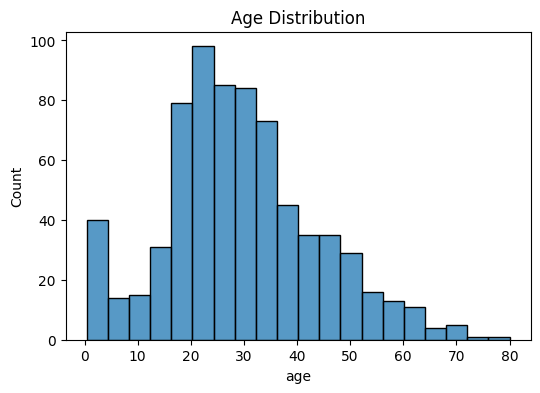

In [ ]:
# [세트 1: 타이타닉 데이터]
def youngest_fare_mean(df: pd.DataFrame) -> float:
    # 1. 'age'가 가장 어린 승객들의 'fare' 평균값 반환
    min_age = df['age'].min()
    return df.loc[df['age'] == min_age, 'fare'].mean()

def pclass_fare_corr(df: pd.DataFrame) -> float:
    # 2. 'pclass'와 'fare'의 상관계수 반환
    return df['pclass'].corr(df['fare'])

def plot_age_histogram(df: pd.DataFrame) -> None:
    # 3. 'age' 분포를 막대 개수(bins) 20개인 히스토그램으로 시각화 (sns.histplot)
    # Figure(도화지)와 Axes(축) 객체 생성
    fig, ax = plt.subplots(figsize=(6, 4))

    # ax 파라미터를 지정하여 해당 축에 히스토그램 그리기
    sns.histplot(data=df, x="age", bins=20, ax=ax)

    # ax 객체의 메서드로 제목 설정
    ax.set_title("Age Distribution")

    # 출력
    plt.show()

print(youngest_fare_mean(titanic_df))
print(pclass_fare_corr(titanic_df))
plot_age_histogram(titanic_df)

3050.0
0.8712017673060111


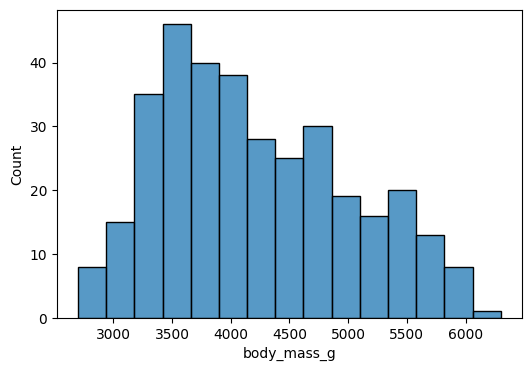

In [ ]:
from pandas.core.indexers import length_of_indexer
# [세트 2: 펭귄 데이터]
def shortest_bill_mass_median(df: pd.DataFrame) -> float:
    # 1. 'bill_length_mm'가 가장 짧은 펭귄들의 'body_mass_g' 중앙값 반환
    bill_min = df['bill_length_mm'].min()
    return df.loc[df['bill_length_mm'] == bill_min, 'body_mass_g'].median()

def flipper_mass_corr(df: pd.DataFrame) -> float:
    # 2. 'flipper_length_mm'와 'body_mass_g'의 상관계수 반환
    return df['flipper_length_mm'].corr(df['body_mass_g'])

def plot_mass_histogram(df: pd.DataFrame) -> None:
    # 3. 'body_mass_g' 분포를 막대 개수(bins) 15개인 히스토그램으로 시각화
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.histplot(data=df, x='body_mass_g', bins=15, ax=ax)
    plt.show()

print(shortest_bill_mass_median(penguin_df))
print(flipper_mass_corr(penguin_df))
plot_mass_histogram(penguin_df)

16.0
-0.8317409332443352


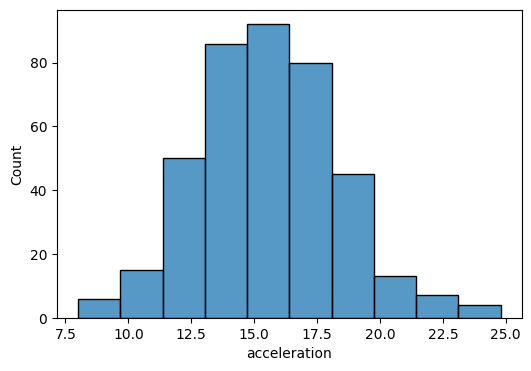

In [ ]:
mpg_df = load_sns_data('mpg')

# [세트 3: 자동차 연비(mpg) 데이터]
def max_hp_mpg_max(df: pd.DataFrame) -> float:
    # 1. 'horsepower'가 가장 높은 자동차들의 'mpg' 최대값 반환
    power_max = df['horsepower'].max()
    return df.loc[df['horsepower'] == power_max, 'mpg'].max()

def weight_mpg_corr(df: pd.DataFrame) -> float:
    # 2. 'weight'와 'mpg'의 상관계수 반환
    return df['weight'].corr(df['mpg'])

def plot_accel_histogram(df: pd.DataFrame) -> None:
    # 3. 'acceleration' 분포를 막대 개수(bins) 10개인 히스토그램으로 시각화
    fig, ax = plt.subplots(figsize=(6,4))
    sns.histplot(data=df, x='acceleration', bins=10, ax=ax)
    plt.show()

print(max_hp_mpg_max(mpg_df))
print(weight_mpg_corr(mpg_df))
plot_accel_histogram(mpg_df)

342


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,1,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,1,1,1,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
6,0,1,0,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
10,1,3,1,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False
11,1,1,1,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True


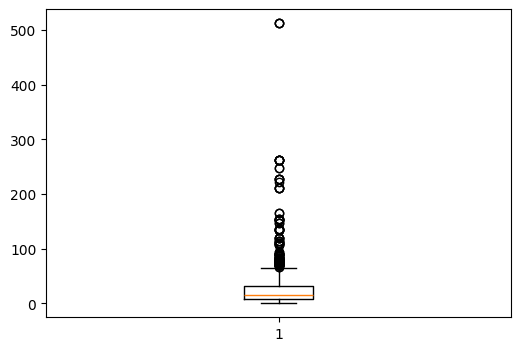

{'whiskers': [<matplotlib.lines.Line2D at 0x7d1af30078c0>,
 'caps': [<matplotlib.lines.Line2D at 0x7d1af3007e30>,
 'boxes': [<matplotlib.lines.Line2D at 0x7d1af3007620>],
 'medians': [<matplotlib.lines.Line2D at 0x7d1af3030320>],
 'fliers': [<matplotlib.lines.Line2D at 0x7d1af3030650>],
 'means': []}

In [ ]:
# [세트 4: 타이타닉 데이터]
def get_survivor_count(df: pd.DataFrame) -> int:
    # 1. 'survived' 컬럼 값이 1인 행의 개수 반환
    return (df['survived'] == 1).sum()

def remove_titanic_nan(df: pd.DataFrame) -> pd.DataFrame:
    # 2. 결측값이 포함된 행을 모두 제거하여 반환
    return df.dropna()

def make_fare_box(df: pd.DataFrame) -> tuple:
    # 3. 'fare' 컬럼에 대한 박스플롯 시각화 (plt.boxplot)
    fig, ax = plt.subplots(figsize=(6, 4))
    box = ax.boxplot(df['fare'])
    plt.show()
    return box

print(get_survivor_count(titanic_df))
display(remove_titanic_nan(titanic_df).head())
make_fare_box(titanic_df)

152


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,0,39.1,18.7,181.0,3750.0,Male
1,Adelie,0,39.5,17.4,186.0,3800.0,Female
2,Adelie,0,40.3,18.0,195.0,3250.0,Female
4,Adelie,0,36.7,19.3,193.0,3450.0,Female
5,Adelie,0,39.3,20.6,190.0,3650.0,Male


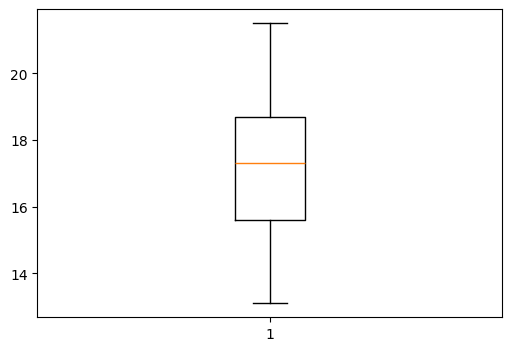

{'whiskers': [<matplotlib.lines.Line2D at 0x7d1af2ec3a10>,
 'caps': [<matplotlib.lines.Line2D at 0x7d1af2ee4050>,
 'boxes': [<matplotlib.lines.Line2D at 0x7d1af2ec3740>],
 'medians': [<matplotlib.lines.Line2D at 0x7d1af2ee4530>],
 'fliers': [<matplotlib.lines.Line2D at 0x7d1af2ee47d0>],
 'means': []}

In [ ]:
# [세트 5: 펭귄 데이터]
def get_adelie_count(df: pd.DataFrame) -> int:
    # 1. 'species' 컬럼 값이 'Adelie'인 행의 개수 반환
    return (df['species'] == 'Adelie').sum()

def remove_sex_nan(df: pd.DataFrame) -> pd.DataFrame:
    # 2. 'sex' 컬럼에 결측값이 있는 행만 제거하여 반환
    return df.dropna(subset=['sex'])

def make_depth_box(df: pd.DataFrame) -> tuple:
    # 3. 'bill_depth_mm' 컬럼에 대한 박스플롯 시각화
    fig, ax = plt.subplots(figsize=(6, 4))
    box = ax.boxplot(df['bill_depth_mm'].dropna())
    plt.show()
    return box

print(get_adelie_count(penguin_df))
display(remove_sex_nan(penguin_df).head())
make_depth_box(penguin_df)

79


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


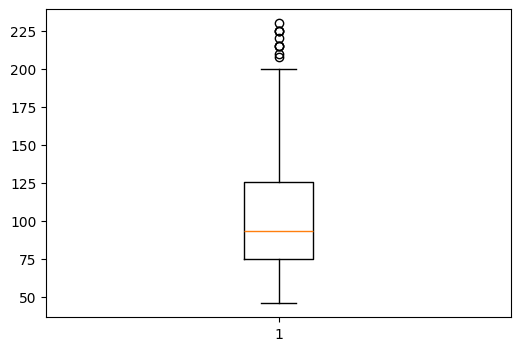

{'whiskers': [<matplotlib.lines.Line2D at 0x7d1af2f70d40>,
 'caps': [<matplotlib.lines.Line2D at 0x7d1af2f71310>,
 'boxes': [<matplotlib.lines.Line2D at 0x7d1af2f70a40>],
 'medians': [<matplotlib.lines.Line2D at 0x7d1af2f717f0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7d1af2f71ac0>],
 'means': []}

In [ ]:
# [세트 6: 자동차 연비(mpg) 데이터]
def get_japan_count(df: pd.DataFrame) -> int:
    # 1. 'origin' 컬럼 값이 'japan'인 행의 개수 반환
    return (df['origin'] == 'japan').sum()

def remove_mpg_nan(df: pd.DataFrame) -> pd.DataFrame:
    # 2. 결측값이 포함된 행을 모두 제거하여 반환
    return df.dropna()

def make_hp_box(df: pd.DataFrame) -> tuple:
    # 3. 'horsepower' 컬럼에 대한 박스플롯 시각화
    fig, ax = plt.subplots(figsize=(6, 4))
    box = ax.boxplot(df['horsepower'].dropna())
    plt.show()
    return box

print(get_japan_count(mpg_df))
display(remove_mpg_nan(mpg_df).head())
make_hp_box(mpg_df)

## 5. 심화 데이터 전처리: 결측치 대체 및 이상치 처리

- 결측치 대체: df['col'].fillna(대체할_값)

  - 단순 제거가 아니라 데이터를 보존하기 위해 평균(mean()), 중앙값(median()) 등으로 결측치를 채웁니다.

- IQR 기반 이상치 제거 (Outlier Removal):

  - Q1(25%)와 Q3(75%)를 df['col'].quantile(0.25), 0.75로 구합니다.
  - IQR = Q3 - Q1

  - 정상 데이터 범위: (Q1 - 1.5 * IQR) 이상 ~ (Q3 + 1.5 * IQR) 이하. 이 범위를 벗어나는 데이터를 필터링합니다.

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,0,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,1,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,1,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,1,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,0,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,0,22.000000,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
2,1,3,1,26.000000,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,1,35.000000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,0,35.000000,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,0,29.699118,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True


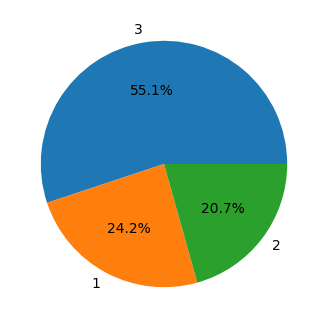

In [ ]:
# [세트 1: 타이타닉 데이터] - df = sns.load_dataset('titanic')
def fill_age_with_mean(df: pd.DataFrame, column: str = 'age'):
    # 1. 'age' 컬럼의 결측값을 해당 컬럼의 평균값으로 대체한 뒤 df 반환
    df[column] = df[column].fillna(df[column].mean())
    return df

def remove_fare_outliers_iqr(df: pd.DataFrame, column: str = 'fare'):
    # 2. 'fare'(요금) 컬럼의 이상치를 IQR 방법을 사용해 제거한 뒤 df 반환
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df.loc[(df[column] >= lower_bound) & (df[column] <= upper_bound), :]
    return df

def draw_pclass_pie(df: pd.DataFrame, column: str = 'pclass'):
    # 3. 'pclass'(객실 등급) 컬럼의 값별 비율을 파이차트로 시각화 (autopct='%1.1f%%')
    counts = df[column].value_counts()
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.pie(counts, labels=counts.index, autopct='%1.1f%%')
    plt.show()

display(fill_age_with_mean(titanic_df).head())
display(remove_fare_outliers_iqr(titanic_df).head())
draw_pclass_pie(titanic_df)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,0,39.1,18.7,181.0,3750.000000,Male
1,Adelie,0,39.5,17.4,186.0,3800.000000,Female
2,Adelie,0,40.3,18.0,195.0,3250.000000,Female
3,Adelie,0,NaN,NaN,NaN,4201.754386,NaN
4,Adelie,0,36.7,19.3,193.0,3450.000000,Female


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,0,39.1,18.7,181.0,3750.0,Male
1,Adelie,0,39.5,17.4,186.0,3800.0,Female
2,Adelie,0,40.3,18.0,195.0,3250.0,Female
4,Adelie,0,36.7,19.3,193.0,3450.0,Female
5,Adelie,0,39.3,20.6,190.0,3650.0,Male


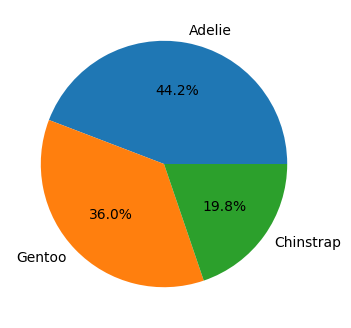

In [ ]:
# [세트 2: 펭귄 데이터] - df = sns.load_dataset('penguins')
def fill_mass_with_mean(df: pd.DataFrame, column: str = 'body_mass_g'):
    # 1. 'body_mass_g'(몸무게) 컬럼의 결측값을 평균값으로 대체한 뒤 df 반환
    df[column] = df[column].fillna(df[column].mean())
    return df

def remove_flipper_outliers_iqr(df: pd.DataFrame, column: str = 'flipper_length_mm'):
    # 2. 'flipper_length_mm'(날개 길이) 컬럼의 이상치를 IQR 방법으로 제거한 뒤 df 반환
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - IQR * 1.5
    upper_bound = Q3 + IQR * 1.5
    df = df.loc[(df[column] >= lower_bound) & (df[column] <= upper_bound), :]
    return df

def draw_species_pie(df: pd.DataFrame, column: str = 'species'):
    # 3. 'species'(종) 컬럼의 값별 비율을 파이차트로 시각화
    fig, ax = plt.subplots(figsize=(6, 4))
    counts = df[column].value_counts()
    ax.pie(counts, labels=counts.index, autopct='%1.1f%%')
    plt.show()

display(fill_mass_with_mean(penguin_df).head())
display(remove_flipper_outliers_iqr(penguin_df).head())
draw_species_pie(penguin_df)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,1,2
1,10.34,1.66,Male,No,Sun,1,3
2,21.01,3.50,Male,No,Sun,1,3
3,23.68,3.31,Male,No,Sun,1,2
4,24.59,3.61,Female,No,Sun,1,4


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,1,2
1,10.34,1.66,Male,No,Sun,1,3
2,21.01,3.50,Male,No,Sun,1,3
3,23.68,3.31,Male,No,Sun,1,2
4,24.59,3.61,Female,No,Sun,1,4


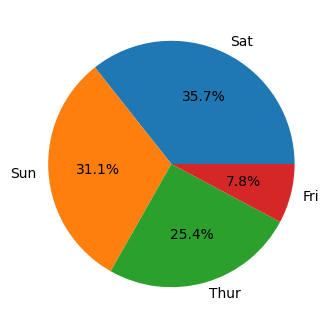

In [ ]:
# [세트 3: 레스토랑 팁 데이터] - df = sns.load_dataset('tips')
def fill_bill_with_mean(df: pd.DataFrame, column: str = 'total_bill'):
    # 1. 'total_bill'(총 결제금액) 컬럼의 결측값을 평균값으로 대체한 뒤 df 반환
    df[column] = df[column].fillna(df[column].mean())
    return df

def remove_tip_outliers_iqr(df: pd.DataFrame, column: str = 'tip'):
    # 2. 'tip'(팁) 컬럼의 이상치를 IQR 방법으로 제거한 뒤 df 반환
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df.loc[(df[column] >= lower_bound) & (df[column] <= upper_bound), :]
    return df

def draw_day_pie(df: pd.DataFrame, column: str = 'day'):
    # 3. 'day'(요일) 컬럼의 값별 비율을 파이차트로 시각화
    counts = df[column].value_counts()
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.pie(counts, labels=counts.index, autopct='%1.1f%%')
    plt.show()

display(fill_bill_with_mean(tip_df).head())
display(remove_tip_outliers_iqr(tip_df).head())
draw_day_pie(tip_df)